# Project 3 — Clustering
## Hotel Customer Segmentation

Camilla Alves. Machine Learning for Marketing — NOVA IMS (2023).

---

### Summary

Unsupervised segmentation of a European hotel's customer base (83,590 customers, 31 raw features). The goal is to move beyond the existing "sales origin" segmentation and produce a data-driven customer segmentation for marketing. Three algorithm families covered in the class are compared under CRISP-DM: **K-Means** (partitioning), **Agglomerative Hierarchical** (with dendrogram and linkage comparison), and **DBSCAN** (density-based).

The final segmentation uses K-Means on PCA-reduced features. Each cluster is characterised by a business persona.


## Business Understanding

Finding new customers is a top priority for hotel groups. To do so efficiently, the marketing team needs to understand the existing customer base and segment it into meaningful groups based on behaviour, revenue, and preferences.

Hotel H's current segmentation is based only on **sales origin** (which channel booked the customer). The new marketing manager wants a data-driven segmentation using the customer database, so the hotel can:

- Define target customer groups
- Tailor products, promotions and pricing per group
- Allocate marketing budget across channels based on the value each channel actually delivers

This project delivers that segmentation using unsupervised learning.


### Dataset description

The dataset covers 83,590 customers with 31 variables — three years of customer behaviour, demographics, geography and room preferences.

| Feature | Description |
|---|---|
| `ID` / `NameHash` / `DocIDHash` | Identifiers (dropped in preparation) |
| `Nationality` | Country of origin |
| `Age` | Age at the end of the extraction period |
| `DaysSinceCreation` | Days since the customer record was created |
| `AverageLeadTime` | Average days between booking and arrival |
| `BookingsCanceled` / `BookingsNoShowed` / `BookingsCheckedIn` | Booking outcomes counts |
| `LodgingRevenue` / `OtherRevenue` | Revenue split (rooms vs food/beverage/spa/other) |
| `PersonsNights` / `RoomNights` | Volume of stays |
| `DaysSinceLastStay` / `DaysSinceFirstStay` | Recency/tenure signals (-1 = never stayed) |
| `DistributionChannel` / `MarketSegment` | Channel and segment metadata |
| `SR*` (13 columns) | Room preferences (high floor, bathtub, crib, king bed, etc.) |


## Initializations and data loading

In [1]:
# Loading packages
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from joblib import dump

RANDOM_STATE = 123
DATA_PATH = Path("../data/HotelCustomersDataset.tsv")
MODEL_DIR = Path("../models"); MODEL_DIR.mkdir(exist_ok=True)
REPORT_DIR = Path("../reports"); REPORT_DIR.mkdir(exist_ok=True)

COLOR_PRIMARY = "#2C3E50"
COLOR_ACCENT  = "#C0392B"
COLOR_TERTIARY = "#16A085"

sns.set_theme(style="whitegrid", context="notebook",
              rc={"axes.spines.top": False, "axes.spines.right": False,
                  "axes.grid.axis": "y", "grid.alpha": 0.25,
                  "axes.titleweight": "semibold", "axes.titlesize": 12,
                  "axes.labelsize": 10})
plt.rcParams["figure.dpi"] = 100


## Data understanding

In [2]:
# Loading the dataset
ds = pd.read_csv(DATA_PATH, sep="\t")
ds.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83590 entries, 0 to 83589
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    83590 non-null  int64  
 1   Nationality           83590 non-null  object 
 2   Age                   79811 non-null  float64
 3   DaysSinceCreation     83590 non-null  int64  
 4   NameHash              83590 non-null  object 
 5   DocIDHash             83590 non-null  object 
 6   AverageLeadTime       83590 non-null  int64  
 7   LodgingRevenue        83590 non-null  float64
 8   OtherRevenue          83590 non-null  float64
 9   BookingsCanceled      83590 non-null  int64  
 10  BookingsNoShowed      83590 non-null  int64  
 11  BookingsCheckedIn     83590 non-null  int64  
 12  PersonsNights         83590 non-null  int64  
 13  RoomNights            83590 non-null  int64  
 14  DaysSinceLastStay     83590 non-null  int64  
 15  DaysSinceFirstStay 

In [3]:
ds.head()

,ID,Nationality,Age,DaysSinceCreation,NameHash,DocIDHash,AverageLeadTime,LodgingRevenue,OtherRevenue,BookingsCanceled,...,SRMediumFloor,SRBathtub,SRShower,SRCrib,SRKingSizeBed,SRTwinBed,SRNearElevator,SRAwayFromElevator,SRNoAlcoholInMiniBar,SRQuietRoom
0,1,PRT,51.0,150,0x8E0A7AF39B633D5EA25C3B7EF4DFC5464B36DB7AF375...,0x71568459B729F7A7ABBED6C781A84CA4274D571003AC...,45,371.0,105.3,1,...,0,0,0,0,0,0,0,0,0,0
1,2,PRT,NaN,1095,0x21EDE41906B45079E75385B5AA33287CA09DE1AB86DE...,0x5FA1E0098A31497057C5A6B9FE9D49FD6DD47CCE7C26...,61,280.0,53.0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,DEU,31.0,1095,0x31C5E4B74E23231295FDB724AD578C02C4A723F4BA2B...,0xC7CF344F5B03295037595B1337AC905CA188F1B5B3A5...,0,0.0,0.0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,FRA,60.0,1095,0xFF534C83C0EF23D1CE516BC80A65D0197003D27937D4...,0xBD3823A9B4EC35D6CAF4B27AE423A677C0200DB61E82...,93,240.0,60.0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,FRA,51.0,1095,0x9C1DEF02C9BE242842C1C1ABF2C5AA249A1EEB4763B4...,0xE175754CF77247B202DD0820F49407C762C14A603B3A...,0,0.0,0.0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
ds.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,83590.0,NaN,NaN,NaN,41795.5,24130.498838,1.0,20898.25,41795.5,62692.75,83590.0
Nationality,83590,188,FRA,12422,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,79811.0,NaN,NaN,NaN,45.398028,16.572368,-11.0,34.0,46.0,57.0,122.0
DaysSinceCreation,83590.0,NaN,NaN,NaN,453.640902,313.390291,0.0,177.0,397.0,723.0,1095.0
NameHash,83590,80642,0xD1490806AB49549565586CE26419163D5EFDD3C607B9...,47,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DocIDHash,83590,76993,0x5FA1E0098A31497057C5A6B9FE9D49FD6DD47CCE7C26...,3657,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AverageLeadTime,83590.0,NaN,NaN,NaN,66.196028,87.75899,-1.0,0.0,29.0,103.0,588.0
LodgingRevenue,83590.0,NaN,NaN,NaN,298.802087,372.851892,0.0,59.0,234.0,402.0,21781.0
OtherRevenue,83590.0,NaN,NaN,NaN,67.589132,114.327776,0.0,2.0,38.5,87.675,7730.25
BookingsCanceled,83590.0,NaN,NaN,NaN,0.002022,0.06677,0.0,0.0,0.0,0.0,9.0


In [5]:
# Missing values
missing = ds.isnull().sum()
missing = missing[missing > 0].to_frame("missing")
missing["percent"] = (missing["missing"] / len(ds) * 100).round(2)
missing


,missing,percent
Age,3779,4.52


**Note.** The dataset has 83,590 rows and 31 columns. Only `Age` has missing values (~4.5% of the rows). `Nationality` has hundreds of unique country codes — too high-cardinality to cluster on directly and is dropped. `NameHash` and `DocIDHash` are anonymisation hashes with no predictive value.

### Categorical exploration — MarketSegment × DistributionChannel

In [6]:
crosstab = pd.crosstab(ds["MarketSegment"], ds["DistributionChannel"], margins=True)
crosstab


DistributionChannel,Corporate,Direct,Electronic Distribution,Travel Agent/Operator,All
MarketSegment,,,,,
Aviation,239,0,0,5,244
Complementary,14,393,0,103,510
Corporate,1724,46,2,397,2169
Direct,14,11219,5,219,11457
Groups,478,134,1,8888,9501
Other,34,96,496,47413,48039
Travel Agent/Operator,97,24,5,11544,11670
All,2600,11912,509,68569,83590


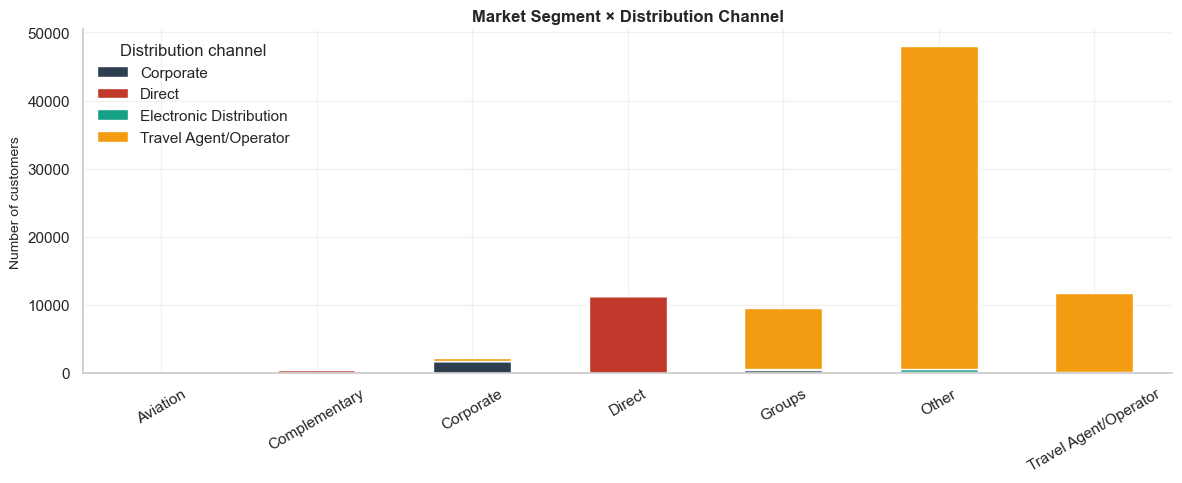

In [7]:
# Stacked bar chart of the cross-table
ct = pd.crosstab(ds["MarketSegment"], ds["DistributionChannel"])
fig, ax = plt.subplots(figsize=(12, 5))
ct.plot(kind="bar", stacked=True, ax=ax,
        color=[COLOR_PRIMARY, COLOR_ACCENT, COLOR_TERTIARY, "#F39C12"])
ax.set_title("Market Segment × Distribution Channel")
ax.set_ylabel("Number of customers")
ax.set_xlabel("")
plt.xticks(rotation=30)
ax.legend(title="Distribution channel", frameon=False)
plt.tight_layout()
plt.show()


**Note.** Travel Agent/Operator dominates the volume across most market segments. Direct and Corporate contribute smaller slices. This is exactly the "sales origin" view that the new marketing wants to move beyond.

### Numeric distributions

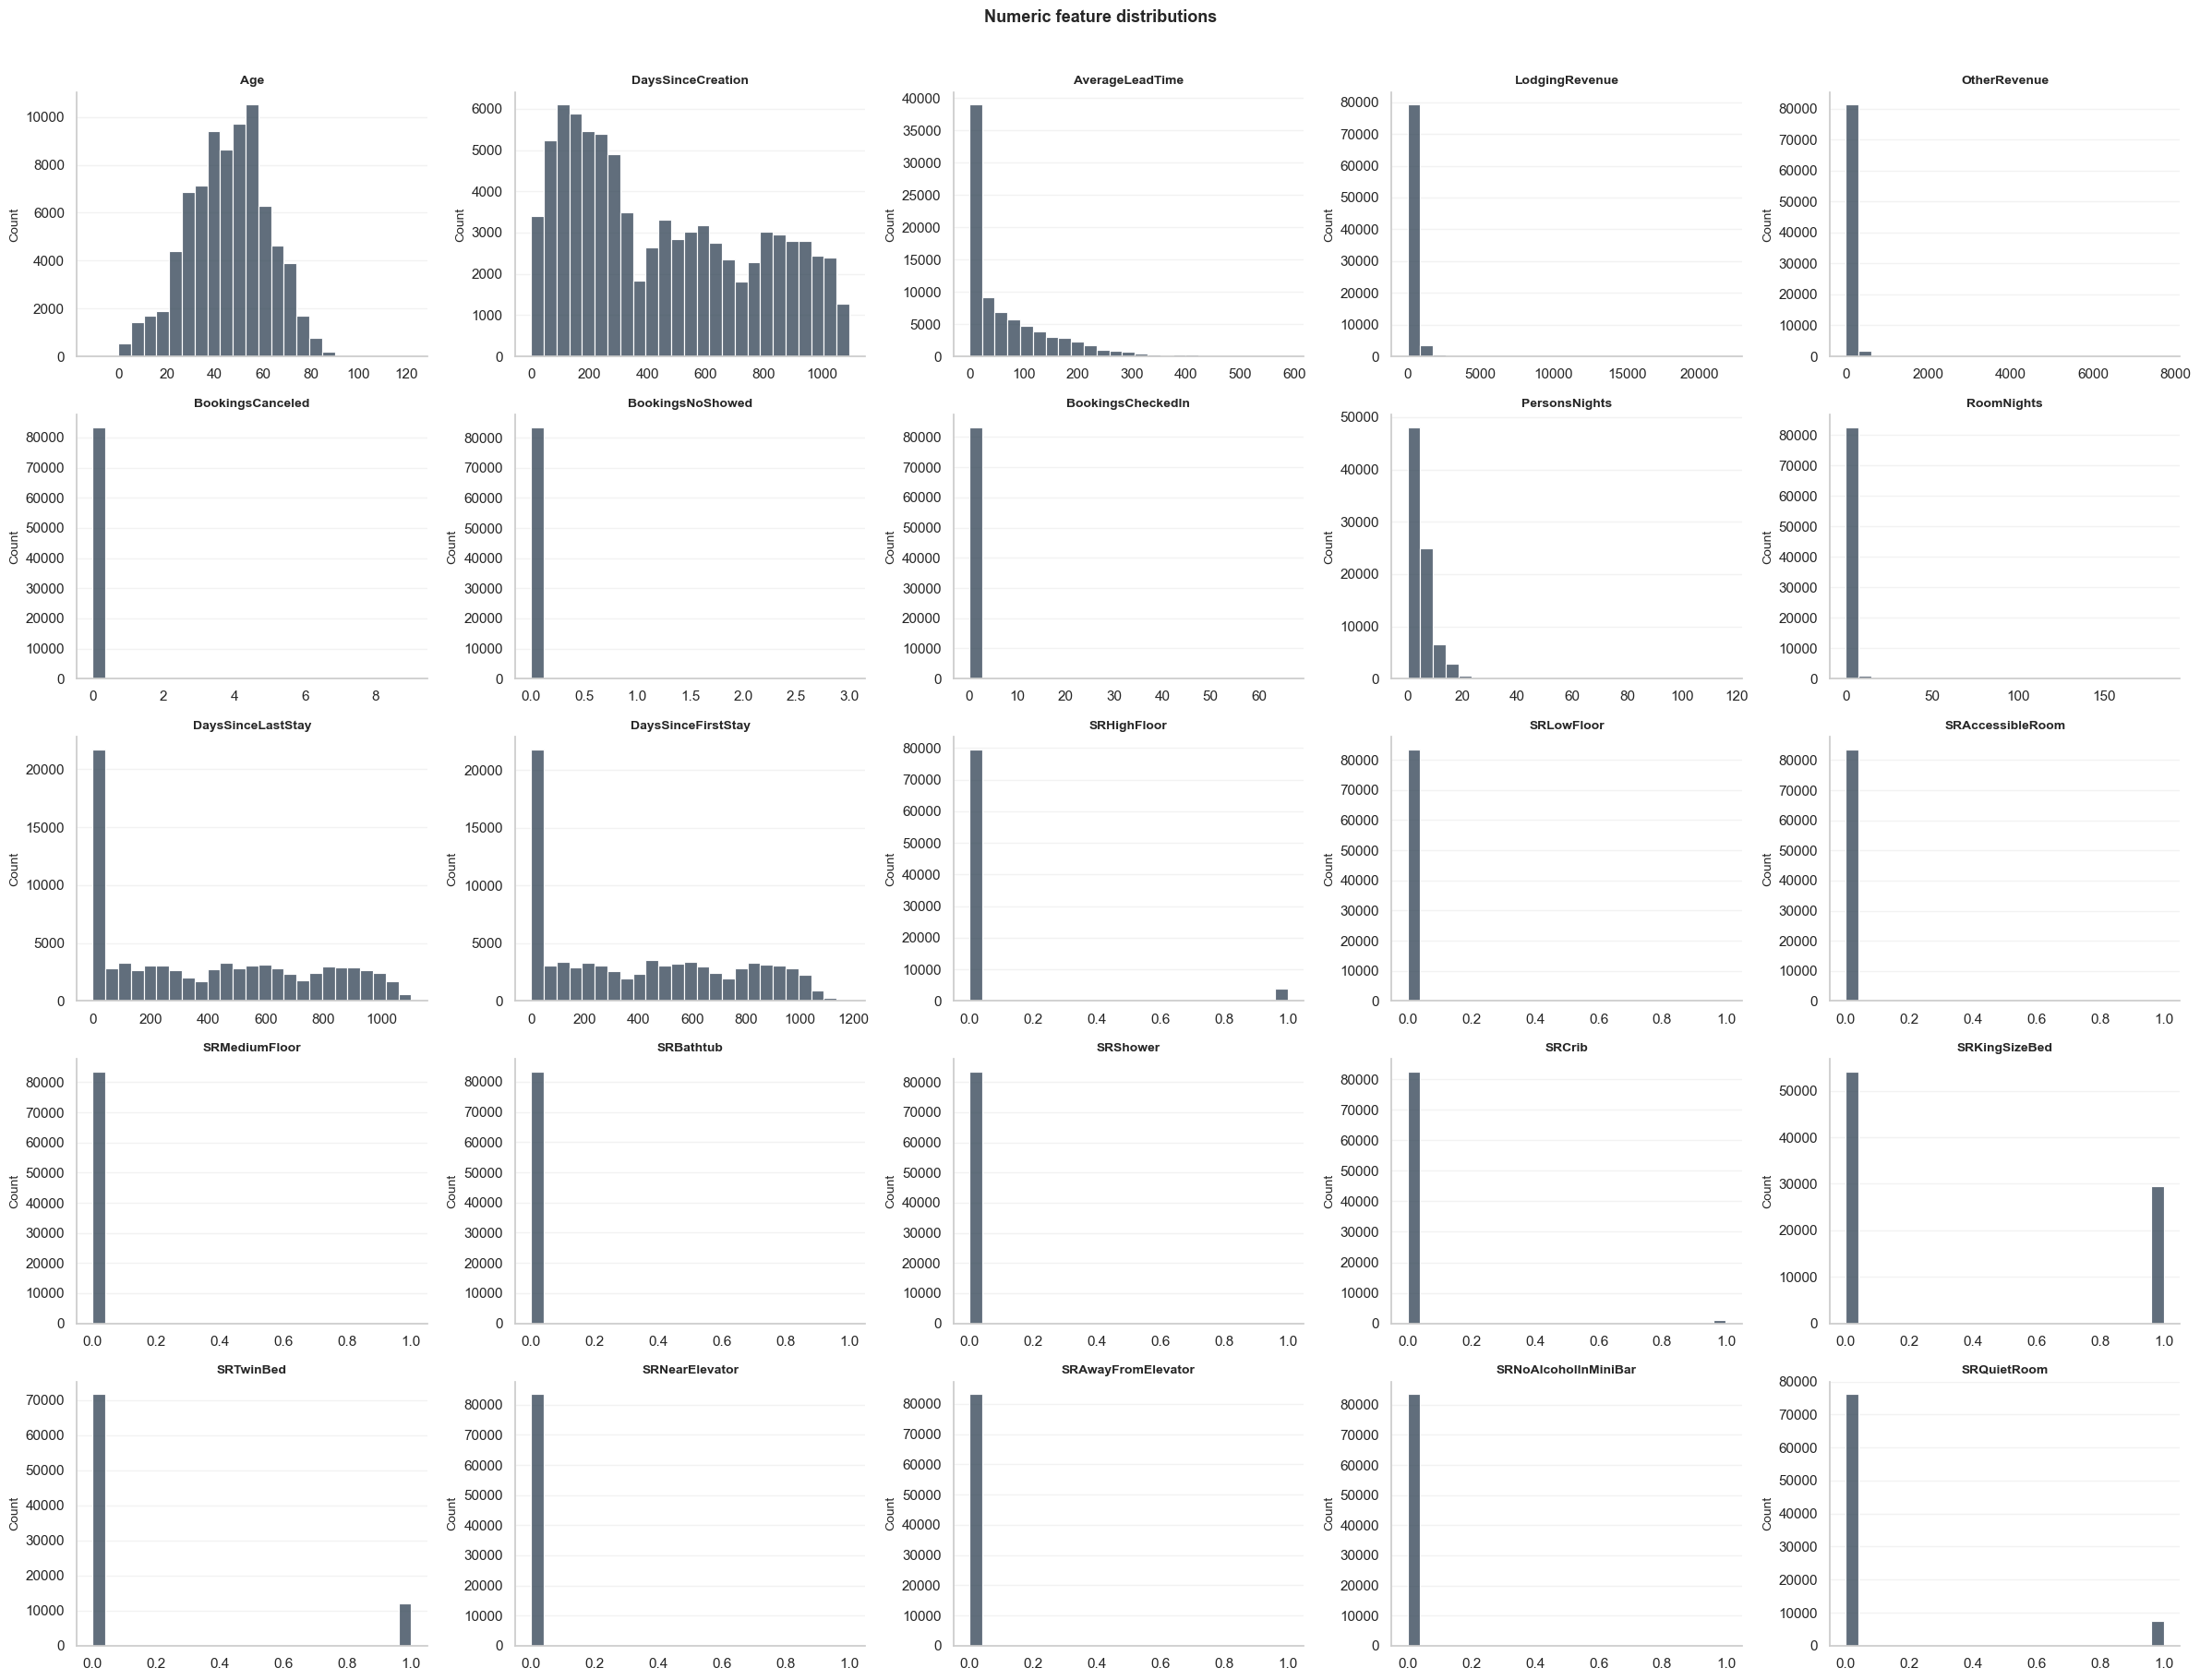

In [8]:
numerical = ds.select_dtypes(include=[np.number]).columns.tolist()
numerical = [c for c in numerical if c not in ("ID",)]

fig, ax = plt.subplots(5, 5, figsize=(24, 18))
for var, subplot in zip(numerical, ax.flatten()):
    sns.histplot(ds[var].dropna(), bins=25, ax=subplot,
                 color=COLOR_PRIMARY, edgecolor="white")
    subplot.set_title(var, fontsize=10)
    subplot.set_xlabel("")

# Turn off unused axes
for j in range(len(numerical), 25):
    ax.flatten()[j].axis("off")

plt.suptitle("Numeric feature distributions", y=1.01, fontsize=13, fontweight="semibold")
plt.tight_layout()
plt.show()


**Note.** Most revenue and stay-volume features are heavily right-skewed — the majority of customers spend little and stay rarely, while a small tail spends a lot. Room preferences (`SR*` columns) are 0/1 binary flags where most values are 0 (no preference expressed).

### Correlation between numeric variables

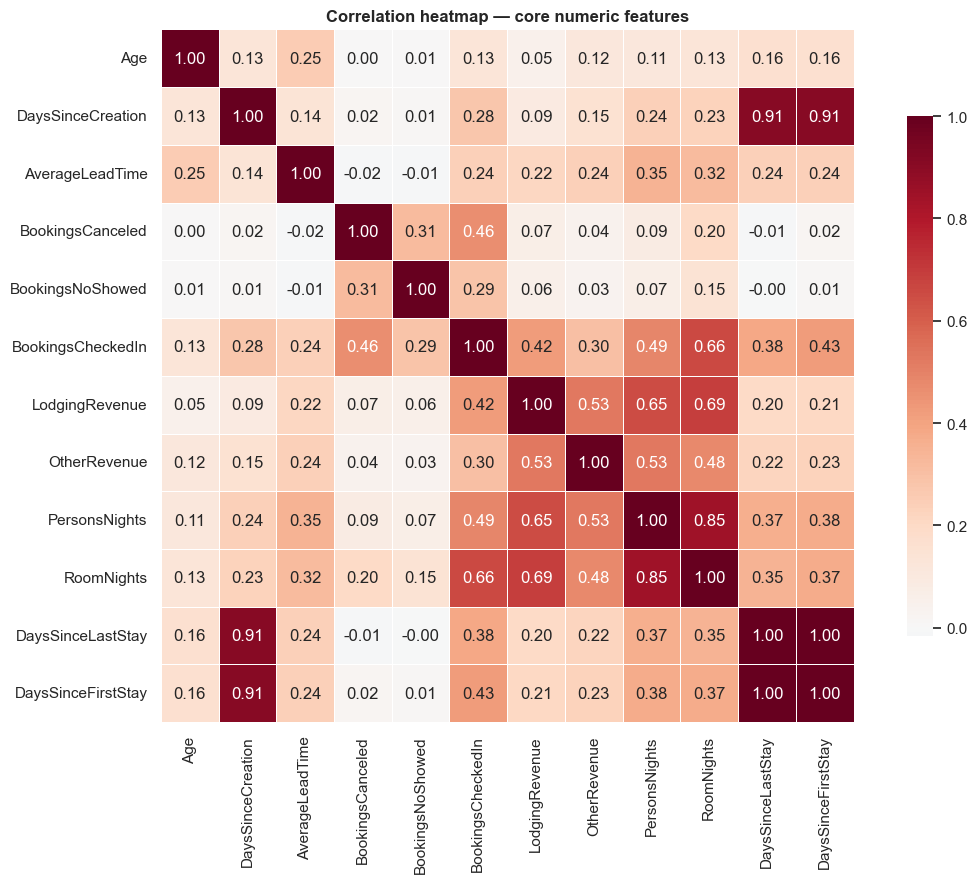

In [9]:
# Correlation on core numeric features (drop the very sparse SR* flags for readability)
core_numeric = ["Age", "DaysSinceCreation", "AverageLeadTime",
                "BookingsCanceled", "BookingsNoShowed", "BookingsCheckedIn",
                "LodgingRevenue", "OtherRevenue", "PersonsNights", "RoomNights",
                "DaysSinceLastStay", "DaysSinceFirstStay"]

plt.figure(figsize=(12, 9))
sns.heatmap(ds[core_numeric].corr(), annot=True, cmap="RdBu_r", center=0,
            fmt=".2f", linewidths=0.5, square=True, cbar_kws={"shrink": 0.75})
plt.title("Correlation heatmap — core numeric features")
plt.tight_layout()
plt.show()


**Note.** Strong correlations:

- `DaysSinceLastStay` ↔ `DaysSinceFirstStay` = **1.00** — perfect correlation. For customers who have stayed only once, the last stay *is* the first stay. One of these is fully redundant with the other in modelling terms.
- `DaysSinceCreation` ↔ both `DaysSinceLastStay` and `DaysSinceFirstStay` = **0.91** — long-tenure customers created their record long ago and their (only) stay is also long ago. Tenure signals move together.
- `PersonsNights` ↔ `RoomNights` = **0.85** — very high, but not identical. `RoomNights` is dropped as redundant.
- `BookingsCheckedIn` ↔ `RoomNights` = **0.66**, ↔ `PersonsNights` = **0.49**, ↔ `LodgingRevenue` = **0.42** — the "did they actually stay" anchor correlates moderately with all volume and revenue signals.
- `LodgingRevenue` ↔ `PersonsNights` = **0.65** and ↔ `RoomNights` = **0.69** — heavy stayers spend more, as expected, but the coupling is only moderate.

Multicollinearity is significant. PCA (used later) is the right tool to handle it — it condenses correlated signals into fewer orthogonal components.


## Data preparation

In [10]:
# Working copy
X = ds.copy(deep=True)

# Drop identifiers, anonymisation hashes, and the redundant/very-sparse columns
drop_cols = [
    "ID", "NameHash", "DocIDHash",          # identifiers, no signal
    "Nationality",                          # too many unique countries
    "RoomNights",                           # redundant with PersonsNights
    "SRLowFloor", "SRMediumFloor", "SRBathtub", "SRShower",
    "SRKingSizeBed", "SRNearElevator", "SRAwayFromElevator",
    "SRNoAlcoholInMiniBar", "SRQuietRoom", "SRHighFloor",
    "SRTwinBed", "SRCrib",                  # too sparse individually
]
X = X.drop(columns=drop_cols)
print(f"Shape after dropping unused columns: {X.shape}")


Shape after dropping unused columns: (83590, 14)


In [11]:
# Age missing values — imputed with the median (~4.5% missing, robust to skew)
median_age = X["Age"].median()
X["Age"] = X["Age"].fillna(median_age)
print(f"Missing values after imputation: {X.isnull().sum().sum()}")


Missing values after imputation: 0


Age summary:
count    83590.0
mean        45.4
std         16.2
min        -11.0
25%         34.0
50%         46.0
75%         56.0
max        122.0
Name: Age, dtype: float64


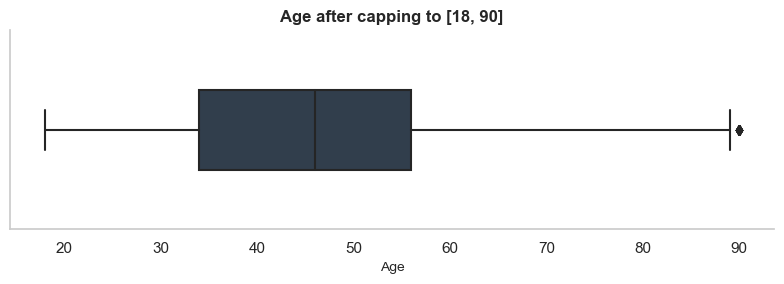

In [12]:
# Age outlier check + capping (some ages exceed 100 which is likely a data-entry issue)
print("Age summary:")
print(X["Age"].describe().round(1))

X["Age"] = X["Age"].clip(lower=18, upper=90)

fig, ax = plt.subplots(figsize=(8, 3))
sns.boxplot(x=X["Age"], ax=ax, color=COLOR_PRIMARY, width=0.4)
ax.set_title("Age after capping to [18, 90]")
plt.tight_layout()
plt.show()


**Note.** Age is imputed with the median (~4.5% missing). Values below 18 or above 90 are capped — a customer of 0 or 130 years old is almost certainly a data-entry error, not a genuine outlier worth preserving.

In [13]:
# One-hot encode DistributionChannel and MarketSegment
X = pd.get_dummies(X, columns=["DistributionChannel", "MarketSegment"], drop_first=False)

# Numeric features summary
print(f"Final shape after encoding: {X.shape}")
X.head()


Final shape after encoding: (83590, 23)


,Age,DaysSinceCreation,AverageLeadTime,LodgingRevenue,OtherRevenue,BookingsCanceled,BookingsNoShowed,BookingsCheckedIn,PersonsNights,DaysSinceLastStay,...,DistributionChannel_Direct,DistributionChannel_Electronic Distribution,DistributionChannel_Travel Agent/Operator,MarketSegment_Aviation,MarketSegment_Complementary,MarketSegment_Corporate,MarketSegment_Direct,MarketSegment_Groups,MarketSegment_Other,MarketSegment_Travel Agent/Operator
0,51.0,150,45,371.0,105.3,1,0,3,8,151,...,0,0,0,0,0,1,0,0,0,0
1,46.0,1095,61,280.0,53.0,0,0,1,10,1100,...,0,0,1,0,0,0,0,0,0,1
2,31.0,1095,0,0.0,0.0,0,0,0,0,-1,...,0,0,1,0,0,0,0,0,0,1
3,60.0,1095,93,240.0,60.0,0,0,1,10,1100,...,0,0,1,0,0,0,0,0,0,1
4,51.0,1095,0,0.0,0.0,0,0,0,0,-1,...,0,0,1,0,0,0,0,0,0,1


In [14]:
# Normalise all columns to [0, 1] — clustering is distance-based, scale matters
X_beforeNorm = X.copy(deep=True)  # kept for interpretation after clustering

scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
print(f"Shape after normalisation: {X_scaled.shape}")
X_scaled.describe().T.round(3).head(10)


Shape after normalisation: (83590, 23)


,count,mean,std,min,25%,50%,75%,max
Age,83590.0,0.386,0.213,0.0,0.222,0.389,0.528,1.0
DaysSinceCreation,83590.0,0.414,0.286,0.0,0.162,0.363,0.660,1.0
AverageLeadTime,83590.0,0.114,0.149,0.0,0.002,0.051,0.177,1.0
LodgingRevenue,83590.0,0.014,0.017,0.0,0.003,0.011,0.018,1.0
OtherRevenue,83590.0,0.009,0.015,0.0,0.000,0.005,0.011,1.0
BookingsCanceled,83590.0,0.000,0.007,0.0,0.000,0.000,0.000,1.0
BookingsNoShowed,83590.0,0.000,0.010,0.0,0.000,0.000,0.000,1.0
BookingsCheckedIn,83590.0,0.012,0.011,0.0,0.015,0.015,0.015,1.0
PersonsNights,83590.0,0.040,0.039,0.0,0.009,0.034,0.052,1.0
DaysSinceLastStay,83590.0,0.364,0.314,0.0,0.024,0.332,0.628,1.0


**Note.** All features are now numeric and scaled to [0, 1]. Clustering algorithms based on distance (K-Means, DBSCAN, agglomerative with euclidean linkage) all require this. Scale-invariant algorithms would not — but here we use scale-sensitive ones, so normalisation is essential.

## Dimensionality reduction — PCA

Class notes flag that clustering on high-dimensional data has two problems: irrelevant features dilute the distance signal, and all points end up looking equally far from each other. PCA reduces the feature space into fewer orthogonal components that capture most of the variance.

In [15]:
# Fit PCA on all features and inspect the explained variance
pca_full = PCA().fit(X_scaled)

evr = pca_full.explained_variance_ratio_
cum_evr = np.cumsum(evr)

evr_df = pd.DataFrame({
    "Component": range(1, len(evr) + 1),
    "Variance explained": evr.round(4),
    "Cumulative": cum_evr.round(4),
})
evr_df.head(20)


,Component,Variance explained,Cumulative
0,1,0.3670,0.3670
1,2,0.2165,0.5835
2,3,0.1749,0.7584
3,4,0.0990,0.8574
4,5,0.0539,0.9112
5,6,0.0346,0.9459
6,7,0.0157,0.9615
7,8,0.0112,0.9727
8,9,0.0076,0.9803
9,10,0.0070,0.9874


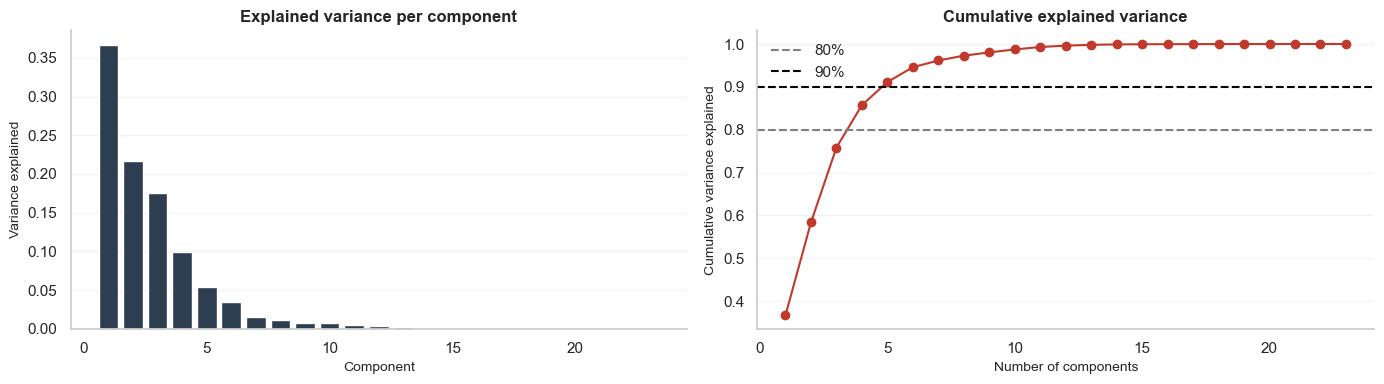

Components to reach 80% variance: 4
Components to reach 90% variance: 5


In [16]:
# Elbow of explained variance
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].bar(range(1, len(evr) + 1), evr, color=COLOR_PRIMARY)
ax[0].set_xlabel("Component")
ax[0].set_ylabel("Variance explained")
ax[0].set_title("Explained variance per component")

ax[1].plot(range(1, len(cum_evr) + 1), cum_evr, marker="o", color=COLOR_ACCENT)
ax[1].axhline(0.80, color="gray", linestyle="--", label="80%")
ax[1].axhline(0.90, color="black", linestyle="--", label="90%")
ax[1].set_xlabel("Number of components")
ax[1].set_ylabel("Cumulative variance explained")
ax[1].set_title("Cumulative explained variance")
ax[1].legend(frameon=False)

plt.tight_layout()
plt.show()

# Find how many components hit 80% and 90%
n_80 = np.argmax(cum_evr >= 0.80) + 1
n_90 = np.argmax(cum_evr >= 0.90) + 1
print(f"Components to reach 80% variance: {n_80}")
print(f"Components to reach 90% variance: {n_90}")


In [17]:
# Apply PCA with enough components to reach ~90% variance
N_COMPONENTS = n_90
pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print(f"Reduced feature space: {X_pca.shape}")


Reduced feature space: (83590, 5)


**Note.** Choosing the number of components: retain enough to cover ~90% of the variance while cutting dimensionality substantially. On this dataset, **5 components** cover 91.1% of the variance — a dramatic reduction from 23 encoded features to just 5. This is the standard rule of thumb at work: enough signal preserved, most noise dropped, distance calculations become much more meaningful.

## Clustering 1 — K-Means (partitioning)

K-Means is the partitioning method from class. It finds K hard clusters of roughly spherical shape by minimising the within-cluster sum of squares (WCSS). K must be chosen upfront — we use two independent methods to pick it.

### Choose K — Elbow method (WCSS)

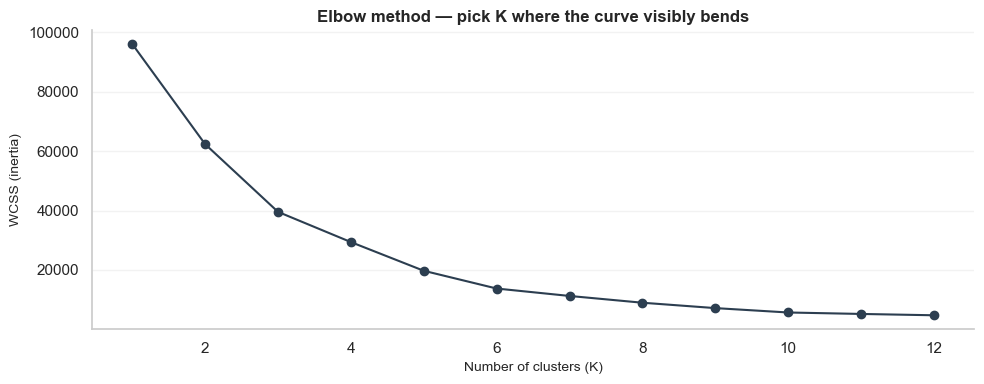

In [18]:
# WCSS (inertia) for K = 1 to 12
wcss = []
K_range = range(1, 13)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    km.fit(X_pca)
    wcss.append(km.inertia_)

plt.figure(figsize=(10, 4))
plt.plot(list(K_range), wcss, marker="o", color=COLOR_PRIMARY)
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS (inertia)")
plt.title("Elbow method — pick K where the curve visibly bends")
plt.tight_layout()
plt.show()


### Choose K — Silhouette method

The silhouette score is computed on a 5,000-row sample. On the full 83k rows it would take several minutes per K.

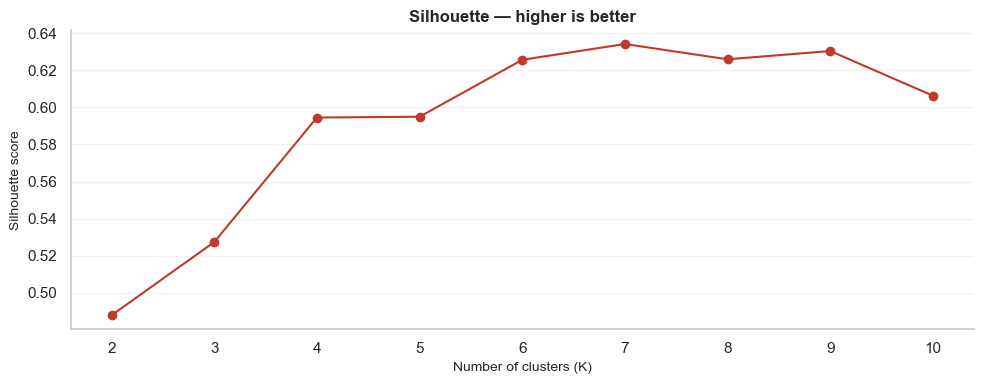

K =  2   silhouette = 0.4878
K =  3   silhouette = 0.5274
K =  4   silhouette = 0.5945
K =  5   silhouette = 0.5950
K =  6   silhouette = 0.6257
K =  7   silhouette = 0.6342
K =  8   silhouette = 0.6260
K =  9   silhouette = 0.6304
K = 10   silhouette = 0.6063


In [19]:
# Silhouette on a subsample (full dataset is too slow)
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(X_pca), size=5000, replace=False)
X_pca_sample = X_pca[sample_idx]

sil_scores = []
K_range_sil = range(2, 11)

for k in K_range_sil:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_pca_sample)
    sil_scores.append(silhouette_score(X_pca_sample, km.labels_))

plt.figure(figsize=(10, 4))
plt.plot(list(K_range_sil), sil_scores, marker="o", color=COLOR_ACCENT)
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette score")
plt.title("Silhouette — higher is better")
plt.tight_layout()
plt.show()

for k, s in zip(K_range_sil, sil_scores):
    print(f"K = {k:2d}   silhouette = {s:.4f}")


**Note.** The elbow curve bends most visibly around K = 3-4, then flattens. The silhouette score climbs steadily and peaks at **K = 7 (0.634)**, with K = 5 at 0.595 and K = 6 at 0.626. The two methods disagree, which is common — the elbow prefers compact clusters (smaller K), the silhouette prefers better-separated clusters (slightly larger K).

**K = 5 is chosen** as the compromise: past the elbow, well above the K = 2-3 baseline on silhouette, and — importantly — a number of segments a marketing team can actually reason about. Seven personas is close to the operational limit; three is too coarse to be useful. Five is where the analytical evidence and the business constraint meet.

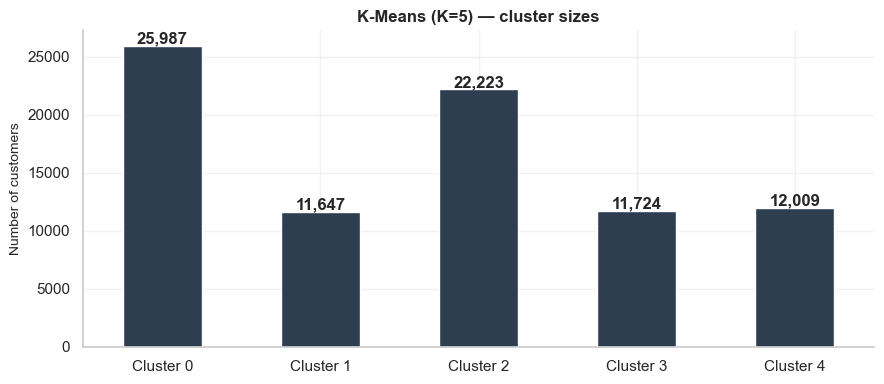

In [20]:
# Fit the final K-Means with the chosen K
K_FINAL = 5
kmeans = KMeans(n_clusters=K_FINAL, n_init=10, random_state=RANDOM_STATE)
kmeans_labels = kmeans.fit_predict(X_pca)

# Cluster sizes
sizes = pd.Series(kmeans_labels).value_counts().sort_index()
sizes.index = [f"Cluster {i}" for i in sizes.index]

fig, ax = plt.subplots(figsize=(9, 4))
sizes.plot(kind="bar", ax=ax, color=COLOR_PRIMARY)
ax.set_title(f"K-Means (K={K_FINAL}) — cluster sizes")
ax.set_ylabel("Number of customers")
ax.set_xlabel("")
for i, v in enumerate(sizes.values):
    ax.text(i, v + 200, f"{v:,}", ha="center", fontweight="semibold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Visualise clusters in 2D (first two PCA components)

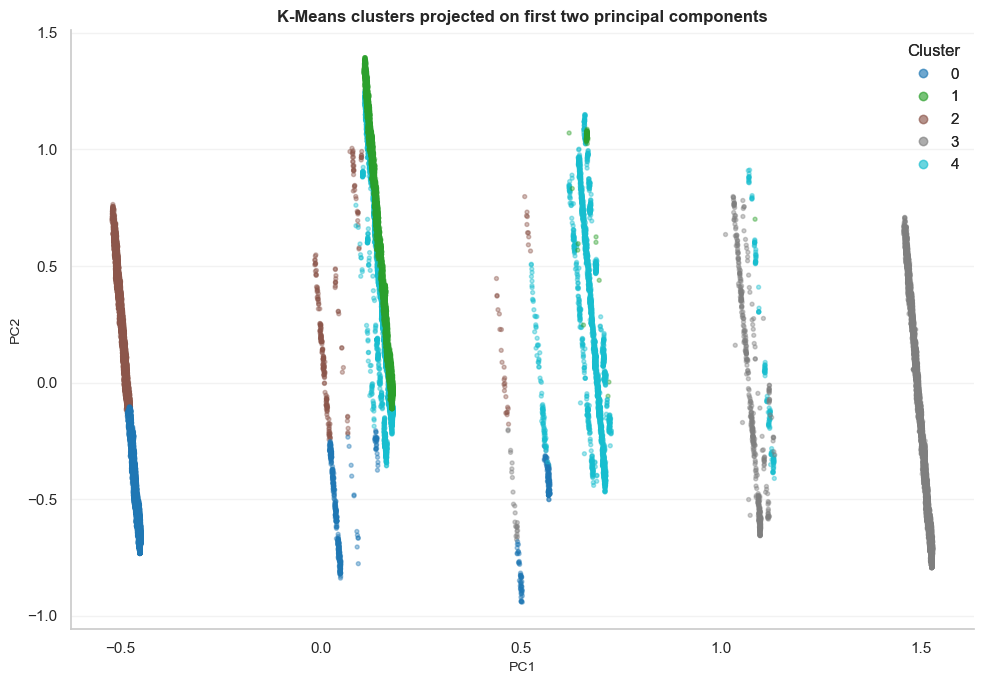

In [21]:
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels,
                     cmap="tab10", alpha=0.4, s=8)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("K-Means clusters projected on first two principal components")
legend = ax.legend(*scatter.legend_elements(), title="Cluster", frameon=False,
                   loc="upper right")
ax.add_artist(legend)
plt.tight_layout()
plt.show()


### Cluster interpretation — K-Means personas

Cluster labels alone are numbers. To make them useful for marketing, we compute the mean of every feature per cluster in the **original scale** (before normalisation), so the numbers are readable.

In [22]:
# Attach labels to the un-normalised dataset for interpretation
X_labeled = X_beforeNorm.copy()
X_labeled["Cluster"] = kmeans_labels

# Group means for interpretation
cluster_summary = X_labeled.groupby("Cluster").mean().round(2)

# Show the most business-meaningful columns
interp_cols = ["Age", "DaysSinceCreation", "AverageLeadTime",
               "BookingsCanceled", "BookingsCheckedIn",
               "LodgingRevenue", "OtherRevenue",
               "PersonsNights", "DaysSinceLastStay", "DaysSinceFirstStay",
               "SRAccessibleRoom"]
interp_cols = [c for c in interp_cols if c in cluster_summary.columns]

cluster_summary[interp_cols].T


Cluster,0,1,2,3,4
Age,42.47,49.28,46.20,43.43,51.34
DaysSinceCreation,205.57,515.55,722.84,410.12,474.75
AverageLeadTime,42.53,100.00,79.44,42.78,82.99
BookingsCanceled,0.00,0.00,0.00,0.00,0.01
BookingsCheckedIn,0.53,0.81,1.01,0.77,0.97
LodgingRevenue,237.53,228.80,408.70,304.12,290.72
OtherRevenue,45.36,74.91,91.59,66.37,65.36
PersonsNights,3.39,5.08,6.62,4.26,3.68
DaysSinceLastStay,109.81,458.31,725.25,346.62,429.06
DaysSinceFirstStay,109.98,459.01,725.91,350.74,438.65


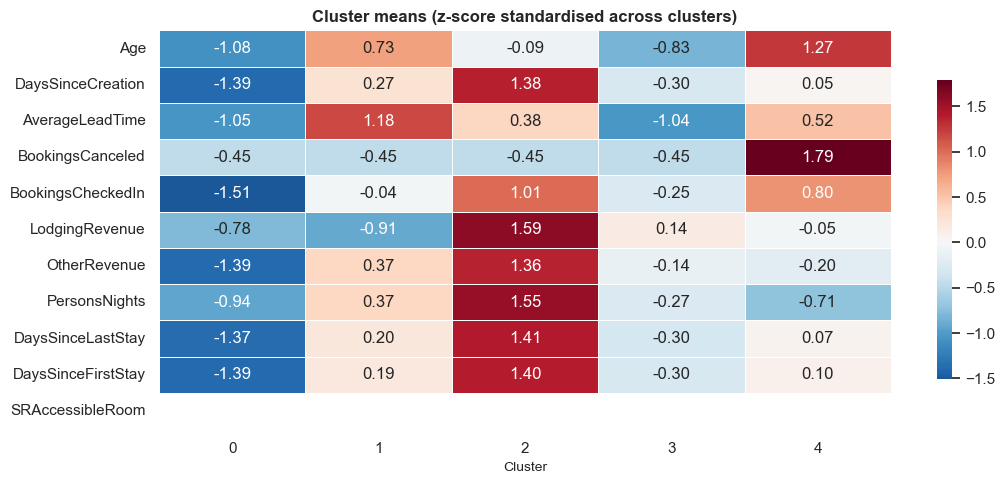

In [23]:
# Heatmap of standardised cluster means — reveals which features distinguish each cluster
means = cluster_summary[interp_cols]
means_z = (means - means.mean()) / means.std()

plt.figure(figsize=(11, 5))
sns.heatmap(means_z.T, annot=True, cmap="RdBu_r", center=0, fmt=".2f",
            linewidths=0.5, cbar_kws={"shrink": 0.75})
plt.title("Cluster means (z-score standardised across clusters)")
plt.xlabel("Cluster")
plt.ylabel("")
plt.tight_layout()
plt.show()


**How to read the heatmap.** Each row is a feature, each column is a cluster. Blue means "this cluster is well below the average of all clusters for this feature"; red means "well above". The strongest colours mark the features that make each cluster distinctive.

**Personas — from the actual output (K = 5, random_state = 123):**

- **Cluster 2 — Loyal high-value (22,223 customers, 27%).** Highest `LodgingRevenue` (408), highest `OtherRevenue` (91), highest `PersonsNights` (6.6), most `BookingsCheckedIn` (1.01). Oldest tenure (722 days since creation). Their last stay was ~725 days ago, though — a lapsed high-value segment worth a retention campaign.
- **Cluster 4 — Reliable-but-cancellers (12,009, 14%).** Oldest age (51.3) and the **only cluster with `BookingsCanceled` > 0**. High check-in rate (0.97) but the cancellations flag them as riskier for pre-paid or non-refundable offers.
- **Cluster 0 — New, low-engagement (25,987, 31%).** Newest tenure (205 days), lowest check-in rate (0.53), lowest revenue. The onboarding segment — target with introductory offers.
- **Cluster 1 — Long-lead planners (11,647, 14%).** Longest `AverageLeadTime` (100 days) by a wide margin. They book far ahead — good candidates for early-bird promotions and structured planning content.
- **Cluster 3 — Middle-of-road active (11,724, 14%).** Mid-tenure, short lead time, moderate on every metric. The "steady regular" that keeps the base warm.


In [24]:
# For each feature, print which clusters rank highest / lowest
print("Cluster ranking per feature (1 = highest cluster on that feature):")
for c in interp_cols:
    ranking = cluster_summary[c].sort_values(ascending=False)
    ranked = " > ".join([f"C{i}" for i in ranking.index])
    print(f"  {c:22s}: {ranked}")


Cluster ranking per feature (1 = highest cluster on that feature):
  Age                   : C4 > C1 > C2 > C3 > C0
  DaysSinceCreation     : C2 > C1 > C4 > C3 > C0
  AverageLeadTime       : C1 > C4 > C2 > C3 > C0
  BookingsCanceled      : C4 > C0 > C1 > C2 > C3
  BookingsCheckedIn     : C2 > C4 > C1 > C3 > C0
  LodgingRevenue        : C2 > C3 > C4 > C0 > C1
  OtherRevenue          : C2 > C1 > C3 > C4 > C0
  PersonsNights         : C2 > C1 > C3 > C4 > C0
  DaysSinceLastStay     : C2 > C1 > C4 > C3 > C0
  DaysSinceFirstStay    : C2 > C1 > C4 > C3 > C0
  SRAccessibleRoom      : C0 > C1 > C2 > C3 > C4


## Clustering 2 — Agglomerative Hierarchical

Bottom-up: every customer starts as its own cluster, then the two closest clusters are merged, repeated until everything joins one root. The result is a **dendrogram** — a tree that shows the merge order and heights. Cutting the tree at a chosen height yields a partition.

Because agglomerative clustering builds a full distance matrix (memory grows as N²), we work on a stratified sample of 5,000 customers. The class methodology is preserved.

In [25]:
# Sample 5,000 customers for the hierarchy
rng = np.random.default_rng(RANDOM_STATE)
hier_idx = rng.choice(len(X_pca), size=5000, replace=False)
X_pca_hier = X_pca[hier_idx]


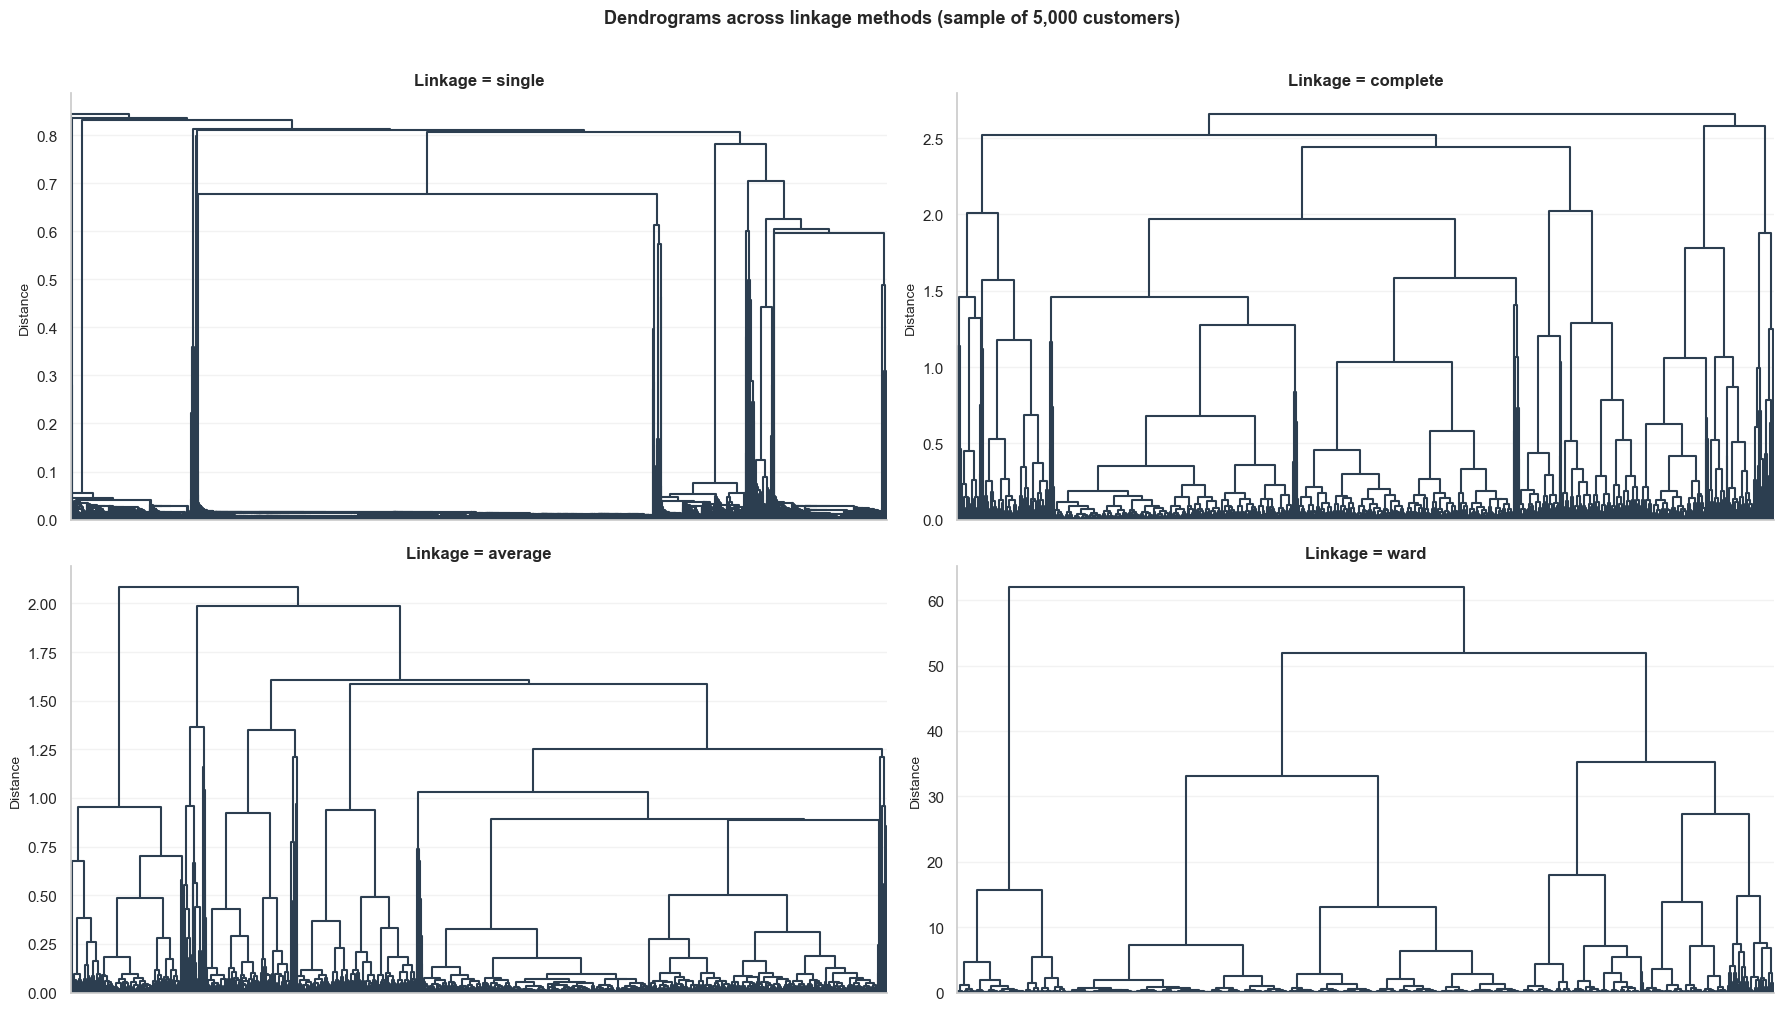

In [26]:
# Compare four linkage methods on the dendrogram
linkage_methods = ["single", "complete", "average", "ward"]

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for ax, method in zip(axes, linkage_methods):
    Z = linkage(X_pca_hier, method=method)
    dendrogram(Z, ax=ax, no_labels=True, color_threshold=0,
               above_threshold_color=COLOR_PRIMARY)
    ax.set_title(f"Linkage = {method}")
    ax.set_xlabel("")
    ax.set_ylabel("Distance")

plt.suptitle("Dendrograms across linkage methods (sample of 5,000 customers)",
             y=1.01, fontsize=13, fontweight="semibold")
plt.tight_layout()
plt.show()


**Note.** Class notes describe the four linkage methods:

- **Single** — distance between the *closest* points of two clusters. Tends to produce long, chained clusters (the "chaining effect"). Sensitive to noise.
- **Complete** — distance between the *farthest* points. Produces compact, roughly equal-size clusters.
- **Average** — average pairwise distance. A middle ground between single and complete.
- **Ward** — minimises the increase in within-cluster variance when merging. Usually gives the most balanced clusters; the default choice for most tabular data.

Ward is the pick here. It produces a dendrogram with clean branches and no chaining.


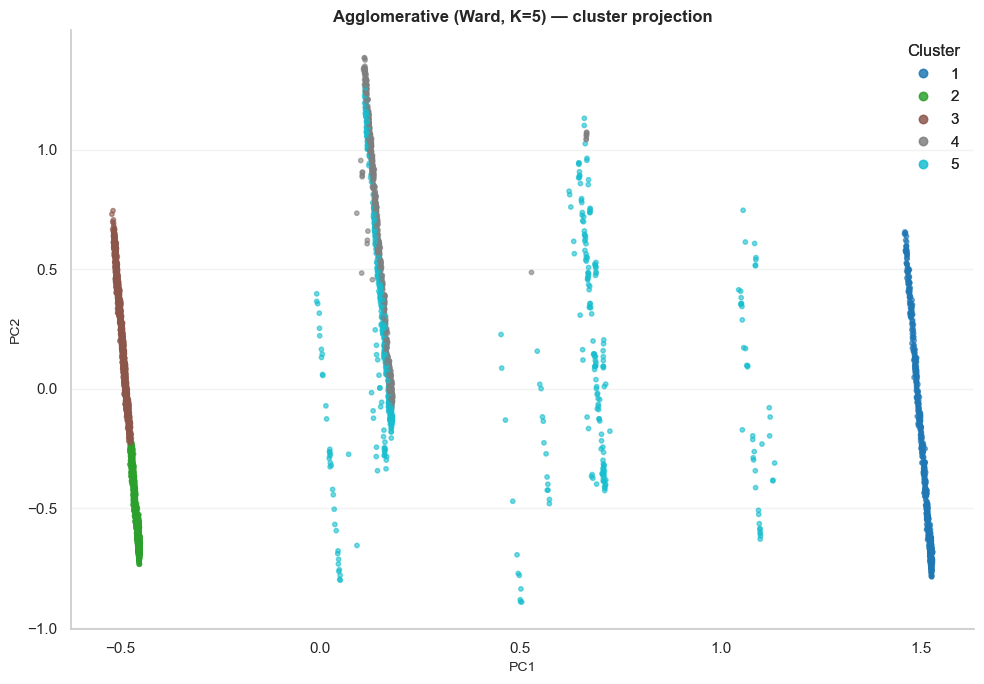

Hierarchical cluster sizes (on the 5k sample):
1     663
2    1368
3    1421
4     748
5     800
dtype: int64


In [27]:
# Ward linkage, then cut the tree to get K clusters
Z_ward = linkage(X_pca_hier, method="ward")
hier_labels_sample = fcluster(Z_ward, t=K_FINAL, criterion="maxclust")

# Visualise the sample clusters in 2D
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(X_pca_hier[:, 0], X_pca_hier[:, 1],
                     c=hier_labels_sample, cmap="tab10", alpha=0.6, s=10)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"Agglomerative (Ward, K={K_FINAL}) — cluster projection")
legend = ax.legend(*scatter.legend_elements(), title="Cluster", frameon=False,
                   loc="upper right")
ax.add_artist(legend)
plt.tight_layout()
plt.show()

# Cluster sizes
sizes_hier = pd.Series(hier_labels_sample).value_counts().sort_index()
print("Hierarchical cluster sizes (on the 5k sample):")
print(sizes_hier)


**Note.** The dendrogram gives an independent view of how the data groups together, and it exposes outliers (points that only merge into the tree at very high distance). The hierarchical result on the sample largely echoes the K-Means structure at the same K — a good sign that the segmentation is stable across method families.

## Clustering 3 — DBSCAN (density-based)

DBSCAN, from the density-based family in class, finds clusters as **dense regions separated by sparse regions**. Unlike K-Means and hierarchical, DBSCAN:

- Does not require picking K upfront
- Can discover clusters of arbitrary shape
- Marks low-density points as **noise** (label = -1) — a built-in outlier detector

It needs two hyperparameters: `eps` (neighbourhood radius) and `min_samples` (minimum points in a neighbourhood to form a dense region). We estimate `eps` from a k-distance plot, which is the standard heuristic.

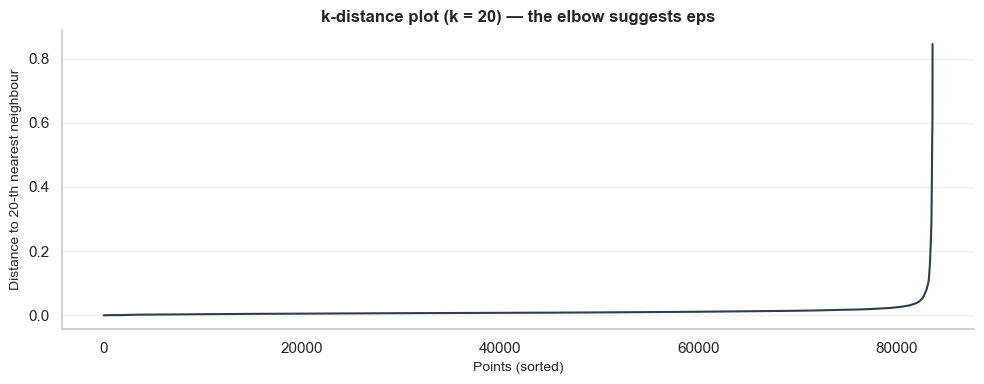

In [28]:
# k-distance plot to pick eps: for each point, distance to the k-th nearest neighbour,
# sorted ascending. The "elbow" of this curve is a reasonable eps.
MIN_SAMPLES = 20
nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES, n_jobs=-1).fit(X_pca)
distances, _ = nbrs.kneighbors(X_pca)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 4))
plt.plot(k_distances, color=COLOR_PRIMARY)
plt.xlabel("Points (sorted)")
plt.ylabel(f"Distance to {MIN_SAMPLES}-th nearest neighbour")
plt.title(f"k-distance plot (k = {MIN_SAMPLES}) — the elbow suggests eps")
plt.tight_layout()
plt.show()


In [29]:
# Fit DBSCAN. eps is set from the elbow of the k-distance plot; tune if needed.
EPS = 0.5
dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, n_jobs=-1)
dbscan_labels = dbscan.fit_predict(X_pca)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)
print(f"DBSCAN — clusters found: {n_clusters_db}")
print(f"DBSCAN — noise points:   {n_noise} ({n_noise/len(dbscan_labels):.1%})")

# Cluster sizes (including noise)
db_sizes = pd.Series(dbscan_labels).value_counts().sort_index()
db_sizes


DBSCAN — clusters found: 15
DBSCAN — noise points:   12 (0.0%)


-1        12
 0      1979
 1     11544
 2     47413
 3     11219
 4       458
 5      8888
 6       478
 7        96
 8       505
 9       134
 10      496
 11      219
 12       92
 13       34
 14       23
dtype: int64

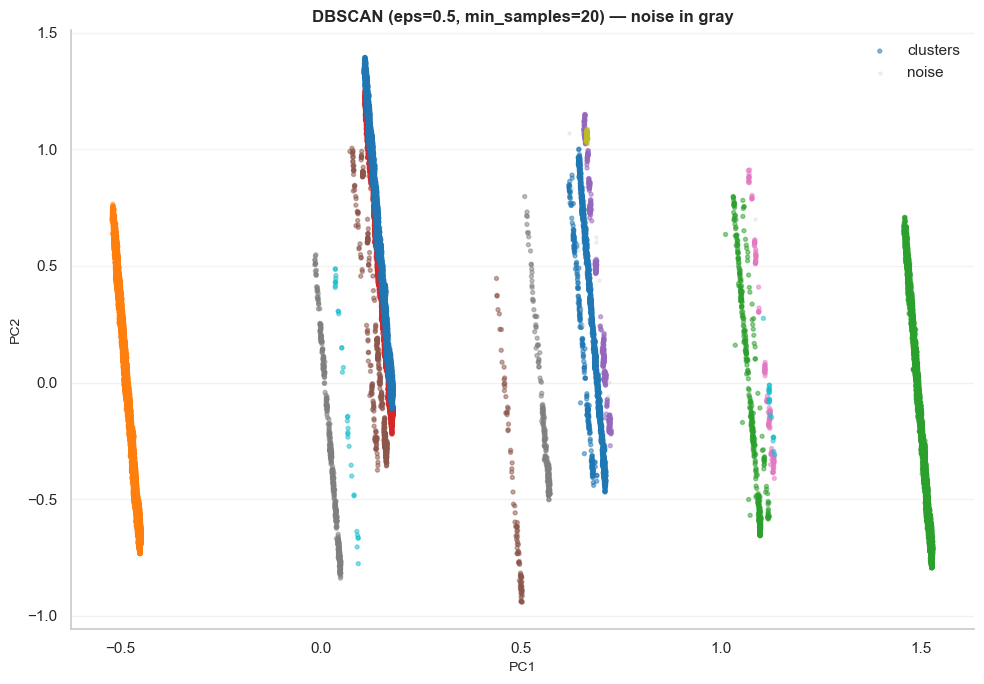

In [30]:
# Visualise DBSCAN in 2D
fig, ax = plt.subplots(figsize=(10, 7))
mask_noise = dbscan_labels == -1

ax.scatter(X_pca[~mask_noise, 0], X_pca[~mask_noise, 1],
           c=dbscan_labels[~mask_noise], cmap="tab10", alpha=0.5, s=8,
           label="clusters")
ax.scatter(X_pca[mask_noise, 0], X_pca[mask_noise, 1],
           color="lightgray", alpha=0.3, s=5, label="noise")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"DBSCAN (eps={EPS}, min_samples={MIN_SAMPLES}) — noise in gray")
ax.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()


**Note.** DBSCAN found **15 clusters** with **only 12 noise points** out of 83,590 (0.014%). That is unusually clean for a density-based method on customer data — the reason is the one-hot encoded `MarketSegment` and `DistributionChannel` columns. Each combination of segment × channel produces its own dense pocket in the PCA space, and DBSCAN follows the geometry.

The largest DBSCAN cluster holds **47,413 customers (57%)** — almost certainly the "Other" market segment dominance we saw in the very first EDA cross-table. The remaining 14 clusters split the smaller channel combinations.

What DBSCAN gives that K-Means does not:

- **Confirmation that the dense pockets in the data align with the categorical segmentation** — a sanity check that the K-Means partition is not fabricating boundaries where none exist.
- **A fine-grained view** — 15 sub-groups is too many for marketing to act on directly, but it exposes that the coarse K-Means groups can be split further if a specific campaign needs it.

For the deployment segmentation, K-Means at K = 5 remains the pick — 15 pockets is operationally too many, and most of them are small.


## Evaluation — which method wins for this dataset?

Clustering is unsupervised, so there is no gold-standard accuracy score. The comparison uses three lenses:

- **Silhouette score** — how well-separated the clusters are (higher is better).
- **Cluster sizes** — very unbalanced sizes are suspicious.
- **Business interpretability** — do the cluster centroids describe personas that a marketing team can act on?

In [31]:
# Silhouette scores on the 5k sample (fair comparison across the three methods)
sample_labels_km  = kmeans.predict(X_pca[hier_idx])
sample_labels_hi  = hier_labels_sample
sample_labels_db  = dbscan_labels[hier_idx]

sil_km = silhouette_score(X_pca[hier_idx], sample_labels_km) \
    if len(set(sample_labels_km)) > 1 else np.nan
sil_hi = silhouette_score(X_pca[hier_idx], sample_labels_hi) \
    if len(set(sample_labels_hi)) > 1 else np.nan
# DBSCAN silhouette excluding noise points
mask_valid = sample_labels_db != -1
sil_db = (silhouette_score(X_pca[hier_idx][mask_valid], sample_labels_db[mask_valid])
          if mask_valid.sum() > 0 and len(set(sample_labels_db[mask_valid])) > 1 else np.nan)

comparison = pd.DataFrame({
    "Method": ["K-Means", "Agglomerative (Ward)", "DBSCAN"],
    "Clusters":    [K_FINAL, K_FINAL, n_clusters_db],
    "Silhouette":  [round(sil_km, 4), round(sil_hi, 4),
                    round(sil_db, 4) if not np.isnan(sil_db) else "n/a"],
    "Noise share": ["0%", "0%", f"{n_noise/len(dbscan_labels):.1%}"],
})
comparison


,Method,Clusters,Silhouette,Noise share
0,K-Means,5,0.5952,0%
1,Agglomerative (Ward),5,0.5787,0%
2,DBSCAN,15,0.4276,0.0%


**Note.** The three methods on the 5,000-customer sample:

- **K-Means** — silhouette **0.5952**, 5 balanced clusters.
- **Agglomerative (Ward)** — silhouette **0.5787**, 5 clusters (very close to K-Means).
- **DBSCAN** — silhouette **0.4276**, 15 clusters (many small ones).

K-Means and Agglomerative land within 0.02 silhouette of each other — a good stability signal, since two independent method families converge on essentially the same partition. DBSCAN's lower silhouette is expected: it splits the space into more, smaller pockets, and silhouette penalises tight per-cluster geometry with many neighbours.

The winner for deployment is **K-Means**: it scales to the full 83k customers without a distance-matrix bottleneck, produces five balanced clusters that each map to a named persona, and matches the Agglomerative result closely enough that we know the partition is stable.

## Deployment

In [32]:
# Ship K-Means as the final segmentation
FINAL_LABELS = kmeans_labels
n_customers = len(FINAL_LABELS)

# Save the labeled dataset for marketing to use
labeled_customers = ds.copy()
labeled_customers["Cluster"] = FINAL_LABELS

out_path = REPORT_DIR / "customer_segments.csv"
labeled_customers[["ID", "Cluster"]].to_csv(out_path, index=False)
print(f"Segment labels saved: {out_path}")


Segment labels saved: ../reports/customer_segments.csv


In [33]:
# Persist model, scaler and PCA transformer for reuse
dump(kmeans, MODEL_DIR / "kmeans_model.joblib")
dump(scaler, MODEL_DIR / "minmax_scaler.joblib")
dump(pca,    MODEL_DIR / "pca_transformer.joblib")

print("Saved:")
print("  models/kmeans_model.joblib")
print("  models/minmax_scaler.joblib")
print("  models/pca_transformer.joblib")
print("\nTo score a new customer:")
print(">>> from joblib import load")
print(">>> model  = load('models/kmeans_model.joblib')")
print(">>> scaler = load('models/minmax_scaler.joblib')")
print(">>> pca    = load('models/pca_transformer.joblib')")
print(">>> cluster = model.predict(pca.transform(scaler.transform(new_customer)))")


Saved:
  models/kmeans_model.joblib
  models/minmax_scaler.joblib
  models/pca_transformer.joblib

To score a new customer:
>>> from joblib import load
>>> model  = load('models/kmeans_model.joblib')
>>> scaler = load('models/minmax_scaler.joblib')
>>> pca    = load('models/pca_transformer.joblib')
>>> cluster = model.predict(pca.transform(scaler.transform(new_customer)))


---
## Scope and limitations

The segmentation covers one European hotel. Generalisation to other hotels in the group (or to different hotel categories) has not been validated — a customer that clusters as "high-value business traveller" here may look different at a leisure-focused property.

`Nationality` was dropped because it has hundreds of unique country codes and would need dedicated encoding (target encoding, region grouping) to be useful. A follow-up run should reintroduce it as region groupings ("Iberian", "Central Europe", "Rest of World", …) — nationality is likely a strong signal that this pass leaves on the table.

Individual room-preference flags (`SR*` columns) were dropped because most are extremely sparse (a few thousand yes-flags out of 83k). Aggregating them into a single "expressed preferences" count would recover some of this signal.

Agglomerative clustering and DBSCAN were run on a 5,000-customer sample because the full distance matrix on 83k rows is too memory-heavy for a laptop. The sample is stratified randomly, but a bootstrap of samples would be needed to prove stability.

The persona names are illustrative. In a real deployment the marketing team should co-author them — the analyst identifies the numeric patterns, the marketing team names the personas in the words their organisation already uses.

---

Author: Camilla Alves.
